We learned about Top K, Top P Sampling, Temperature, KV Caching, Prompt Caching

## Top K Sampling

**Definition:**  
Top K sampling is a text generation strategy where the model only considers the `K` most likely next tokens and ignores the rest.

For example, if `K = 5`, the model chooses the next token only from the top 5 highest-probability tokens.

**Use Case Example:**  
Use Top K sampling when you want the model to produce creative responses while still limiting extremely unlikely or random words.

Example:
- `Top K = 1`: very deterministic, similar to always choosing the most likely word
- `Top K = 50`: more variety and creativity
- `Top K = 100`: even more diverse, but may become less focused

**Practical Use:**  
Good for chatbots, story generation, brainstorming, and creative writing where some randomness is useful.

## Top P Sampling

**Definition:**  
Top P sampling, also called nucleus sampling, chooses from the smallest group of tokens whose combined probability is at least `P`.

For example, if `P = 0.9`, the model considers only the most likely tokens that together make up 90% of the probability mass.

**Use Case Example:**  
Use Top P when you want the model to dynamically adjust how many tokens it considers based on confidence.

Example:
- If the model is very confident, it may choose from only a few tokens
- If the model is uncertain, it may choose from a larger set of tokens

**Practical Use:**  
Good for open-ended generation, summaries, conversational AI, and content creation where you want balanced creativity and coherence.

## Temperature

**Definition:**  
Temperature controls how random or predictable a model’s output is.

A lower temperature makes the model more focused and deterministic.  
A higher temperature makes the model more creative and random.

**Use Case Example:**  
Use temperature to control the creativity level of the response.

Example:
- `Temperature = 0`: most deterministic, useful for factual answers
- `Temperature = 0.2`: focused and consistent
- `Temperature = 0.7`: balanced creativity
- `Temperature = 1.0+`: more creative, but may be less accurate

**Practical Use:**  
Use low temperature for coding, math, classification, and factual Q&A.  
Use higher temperature for brainstorming, creative writing, marketing copy, and idea generation.

## KV Caching

**Definition:**  
KV caching stands for Key-Value caching. It is a technique used by transformer models to store previously computed attention keys and values during text generation.

Instead of recalculating attention for the entire prompt every time the model generates a new token, the model reuses the cached keys and values.

**Use Case Example:**  
When a model generates a long answer, it produces tokens one at a time. Without KV caching, the model would repeatedly recompute the same earlier context. With KV caching, it only computes the new token’s information and reuses the previous context.

**Practical Use:**  
KV caching is useful for:
- Faster text generation
- Lower latency in chatbots
- Streaming responses
- Long conversations
- Reducing repeated computation during inference

## Prompt Caching

**Definition:**  
Prompt caching is a technique where repeated parts of a prompt are stored and reused so the model does not need to process the same input from scratch every time.

This is especially useful when many requests share the same system prompt, instructions, documents, or context.

**Use Case Example:**  
Imagine an application where every request includes the same long company policy document. With prompt caching, the model can reuse the processed version of that document instead of reprocessing it for every user question.

**Practical Use:**  
Prompt caching is useful for:
- Reducing latency
- Lowering cost
- Reusing long system prompts
- Chatbots with fixed instructions
- Retrieval-Augmented Generation, or RAG, workflows
- Applications that repeatedly include the same context

## Prefix Matching in Prompt Caching

**Definition:**  
Prefix matching means the model checks whether the beginning part of a new prompt matches a prompt segment that was processed before.

If the start of the prompt is the same as a previously cached prompt, the model can reuse the cached computation for that matching prefix instead of processing it again from scratch.

In simple terms:

> If two prompts start the same way, the shared beginning can be cached and reused.

## Example

Request 1:

```text
System: You are a helpful AWS certification tutor.
Context: Here are the course notes about foundation models...
User: Explain temperature.

System: You are a helpful AWS certification tutor.
Context: Here are the course notes about foundation models...
User: Explain Top P sampling.

System: You are a helpful AWS certification tutor.
Context: Here are the course notes about foundation models...

The beginning of both prompts is the same: With prefix matching, the model can reuse the cached processing for that repeated prefix and only process the new user question.

**If you want to fine tune a model in AWS bedrock with sensitive data**

Use

- VPC
- Private Link

**Fine Tuning**

So for normal fine tuning , we can use a dataset like {prompt:"What is the state of USA?" Completion: "Ohio is a state of USA " } {...}{...} like some few shot examples with a defined format (**labled training pair**) in s3 , the we can use it to fine tune the model

**Continued Pretraining**

Fine tuning with Unlabled dataset . just feeding it to the model to familiarize the model with the data

**LORA** **LOW RANK ADAPTATION MATRICES**

Freeze the original model weights (d*k)

Add the adapation matrces with the same dimensions as original models like (d x r)( r x k) which eventually comes up with the dimension(d x k).

During inference add it top of the existing layers

**RAG in AWS Bedrock**

Knowledge Bases in Bedrock : you can add JSON(structured data) or unstructered data in any of these services

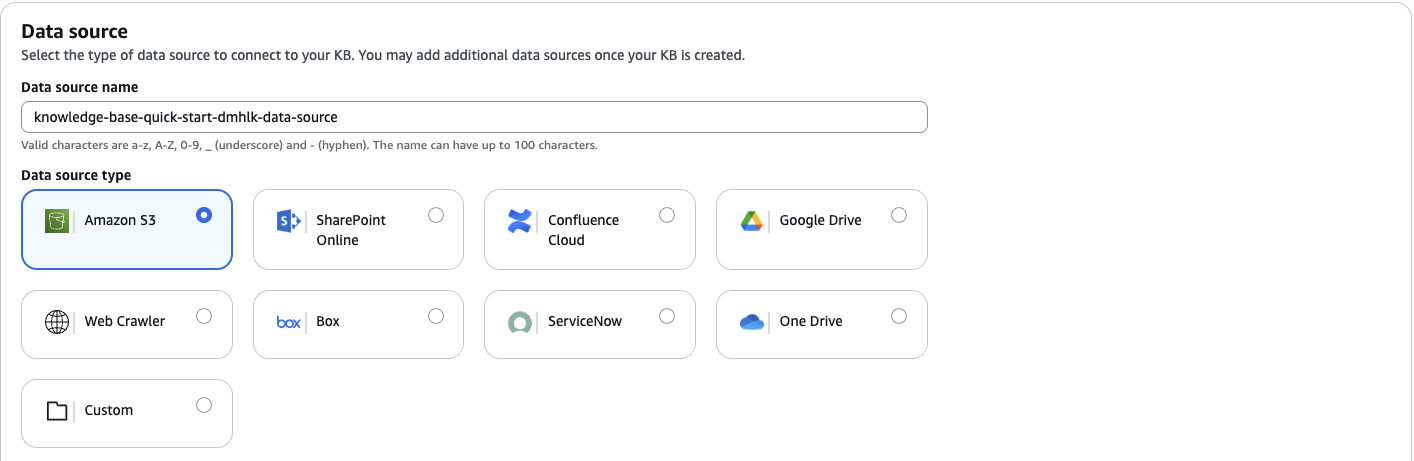

**Embedding Models available in AWS Bedrock**

Titan, Cohere

**Vector Store**

OpenSearch (Serverless)
Amazon S3 vectors (best pricing)
Amazon Aurora postgreSQL
Amazon Neptune Analytics(GraphRAG)
Third-party options include Pinecone, Redis Enterprise Cloud, and MongoDB Atlas

**Maximum no of tokens per chunk**

This is based on the requirement , basically each chunk will consist n tokens, relevant to the query

**Chunk Overlap** 

Chunk overlap prevents important information from being lost at chunk boundaries.

** Test Environment in AWS bedrock **

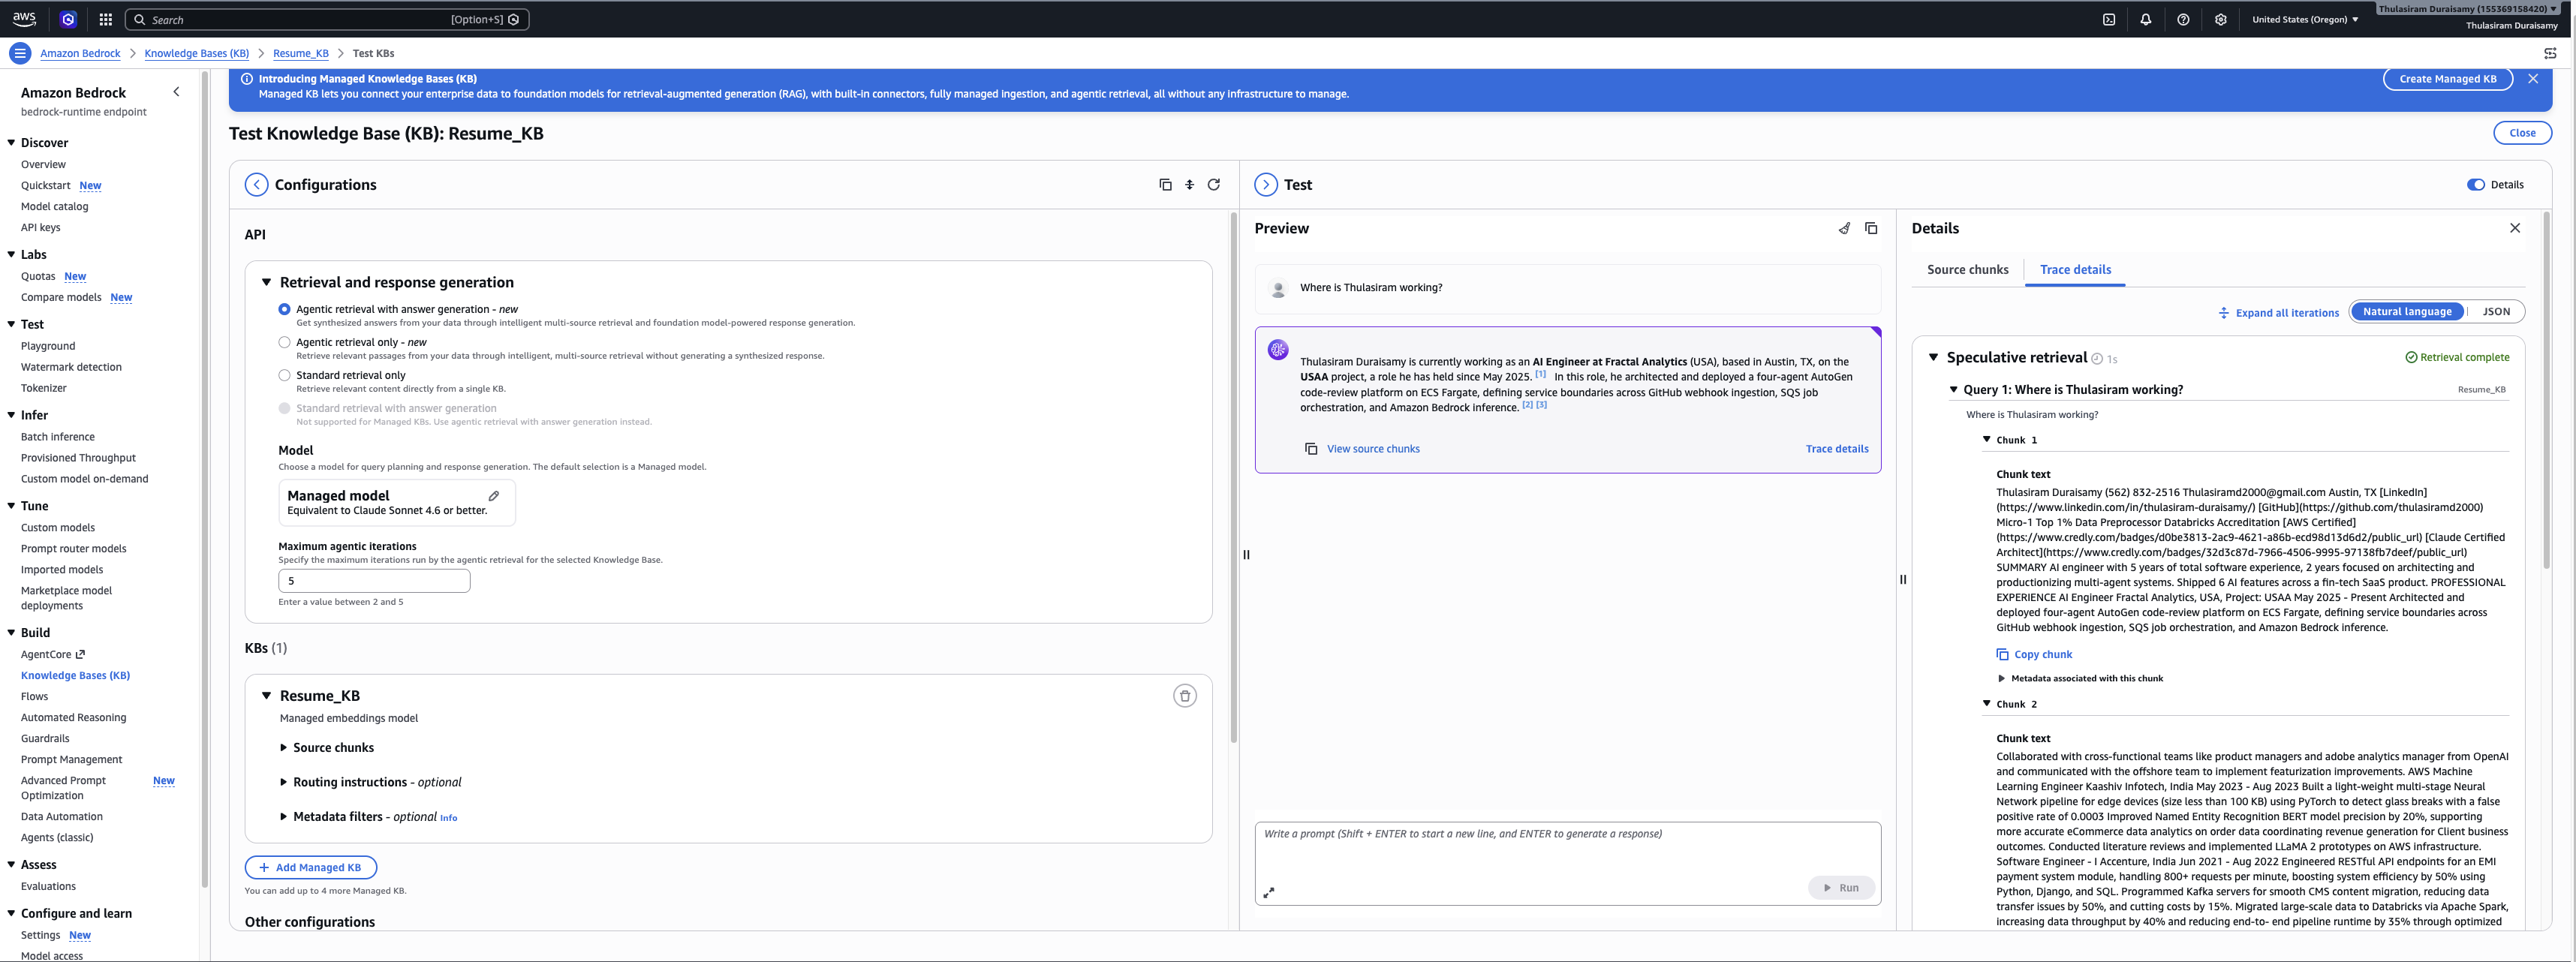

In order to use or compare multiple models within a use, we have this following ways.

FOr local development purpose , we can use oprn router API, to send same prompts.

But for production environments in AWS , we can AWS Converse API, where this is a post method where each model has different params

OpenRouter makes sense when you want fast prototyping, maximum model variety, minimal setup, or you're building something model-agnostic and want to compare many providers quickly. Great for indie projects, hackathons, and multi-agent setups where different agents use different models.

Bedrock Converse makes sense when you're already on AWS, need enterprise governance (IAM, logging, compliance), want private networking, or need guaranteed throughput. It's the natural fit if your production stack is AWS-native.

LLAMA INDEX

Llama Index is basically a data ingestion and data indexing framework used during the pre-retrieval phase (chunking ---> embedding)

Documents → [LlamaIndex: Load + Chunk] → [Embedding Model: vectorize]
    → [LlamaIndex: Index + Store in Vector DB]
    
Query → [LlamaIndex: embed query] → [Vector DB: similarity search]
    → [LlamaIndex: retrieve nodes + build prompt] → [LLM: generate]
    → [LlamaIndex: return synthesized response]

LlamaIndex's edge: richer indexing strategies (tree index, knowledge graph index, auto-merging retrieval), retrieval evaluation tooling, and generally tighter defaults specifically tuned for retrieval quality.

Chunking Types in Bedrock Knowledge base:

Fixed chunking: nothing fancy, allocating fixed number of tokens per chunk and fixed number of overlaps between chunks. 

Eg : Chunk tokens: 20 
     Overlap: 3

Hierarchichal Chunking: This is a parent child chunking. Lets say we have a doc of 50 tokens. we divide it to 15 chunks per parent and the parent chunk is again divided into 7 or 8 chunks as child chunks  with overlaps as we need. SO while retireving we will hit the child chunk and retireve the parent chunk for more context.

Eg: Parent chunk: 15
    Child chunk: 7
    Overlap: 1

```mermaid
flowchart TD
    D["Document"] --> S1["Section 1"]
    D --> S2["Section 2"]

    S1 --> P11["Paragraph 1.1"]
    S1 --> P12["Paragraph 1.2"]
    S2 --> P21["Paragraph 2.1"]
    S2 --> P22["Paragraph 2.2"]

    P11 --> C111["Chunk 1.1.1"]
    P11 --> C112["Chunk 1.1.2"]
    P12 --> C121["Chunk 1.2.1"]
    P21 --> C211["Chunk 2.1.1"]
    P22 --> C221["Chunk 2.2.1"]
    P22 --> C222["Chunk 2.2.2"]

    classDef root fill:#1d4ed8,color:#fff,stroke:#1e3a8a
    classDef section fill:#7c3aed,color:#fff,stroke:#4c1d95
    classDef paragraph fill:#0f766e,color:#fff,stroke:#134e4a
    classDef chunk fill:#fef3c7,color:#78350f,stroke:#d97706

    class D root
    class S1,S2 section
    class P11,P12,P21,P22 paragraph
    class C111,C112,C121,C211,C221,C222 chunk
```
```mermaid
flowchart LR
    Q["User query"] --> E["Create query embedding"]
    E --> R["Search small chunks"]
    R --> M["Find best matches"]
    M --> P["Fetch parent context"]
    P --> RR["Rerank and filter"]
    RR --> L["Send context to LLM"]
```

## Semantic Chunking in Amazon Bedrock

Semantic chunking divides a document at changes in meaning instead of splitting it only by a fixed number of tokens. During data-source ingestion, Amazon Bedrock compares adjacent sentences (or buffered sentence groups), identifies unusually dissimilar transitions, creates chunk boundaries at those transitions, and stores an embedding for each resulting chunk in the vector database. The retriever later searches these stored chunk embeddings; it does not calculate the breakpoint threshold at query time.

### Configuration

1. **Maximum tokens:** The maximum number of tokens allowed in one chunk. Bedrock further splits a semantic chunk if it exceeds this limit.
2. **Buffer size:** The number of surrounding sentences included when creating the representation used to compare sentences. In Bedrock, `0` compares each sentence by itself, while `1` uses the previous, current, and next sentences. More context can make boundaries more coherent, but it can also smooth over smaller topic changes.
3. **Breakpoint percentile threshold:** The percentile of sentence-pair dissimilarity above which Bedrock creates a new chunk boundary. This is a percentile ranking across the sentence comparisons, not a raw similarity score and not a vector-database retrieval threshold.

### How to interpret the breakpoint threshold

- **Higher threshold (for example, 95):** Only approximately the 5% most dissimilar transitions become breakpoints. It is harder to create a split, so the result is **fewer, larger chunks**.
- **Lower threshold (for example, 60):** Approximately the 40% most dissimilar transitions become breakpoints. It is easier to create a split, so the result is **more, smaller chunks**.

> Memory rule: **Higher threshold = harder to break = fewer chunks. Lower threshold = easier to break = more chunks.**

For example, with 101 sentences there are 100 adjacent sentence pairs. A threshold of `90` selects approximately the 10 pairs with the highest dissimilarity as breakpoints, subject to the maximum-token limit.

One more thing , amazon bedrock uses foundation models to create semantic representations which is used to calculate dissimilarity scores (breakpoint threshold comparison). 

So gotta use it wisely according to the requirement, due to budget.

```mermaid
flowchart TD
    D["Document"] --> S["Split into sentences"]
    S --> E["Create sentence or buffered-group embeddings"]
    E --> C["Calculate adjacent dissimilarities"]
    C --> T{"Above breakpoint percentile?"}
    T -- "Yes" --> B["Start a new chunk"]
    T -- "No" --> K["Keep in the same chunk"]
    B --> V[("Embed and store resulting chunks")]
    K --> V
```


The important detail is that Bedrock’s 95 threshold does not mean “split when dissimilarity is 0.95.”
It means:
Split at boundaries whose dissimilarity is in the highest 5% among the sentence pairs being evaluated.

### Dimensions of an Embedding Vector

A dimension is one coordinate or position in an embedding vector. Each
dimension contains a numerical value, usually a floating-point number.

For example, an embedding model might convert the sentence:

> I am super intelligent.

into a simplified four-dimensional vector:

`[28.0, -9.5, 84.0, 27.0]`

In this vector, `28.0` is the value at the first dimension, `-9.5` is the
value at the second dimension, and so on. The meaning of the sentence is
represented collectively by all dimensions; an individual dimension
usually does not correspond to a simple human-readable concept.

Amazon Titan Text Embeddings V2 can represent the same sentence as a
1,024-dimensional vector:

`[x₁, x₂, x₃, ..., x₁₀₂₄]`

The larger number of dimensions gives the model more representational
capacity to encode semantic relationships learned during training.
However, more dimensions do not automatically guarantee better retrieval.

The embedding model creates the vector in its learned embedding space.
The vector database stores and compares these vectors but does not create
their semantic meaning. 

## Why Are Sparse Embeddings High-Dimensional?

Sparse vectors are high-dimensional because they usually reserve **one dimension for every term in the complete vocabulary**, not only for the words found in the current sentence or document.

### Simple Example

Assume the complete vocabulary contains six terms:

`text
[amazon, bedrock, database, embedding, security, vector]


The sentence:

> Amazon uses a database.

can be represented as:

```text
[1, 0, 1, 0, 0, 0]

So dense embeddings are more memory efficient and more semantic accuracy as well. 

Sparse vectors gives great similarity factors (cosine similarity)

We can also optimize embedding retrieval using metadata.

We can also store the .json file which consists the metadata of the document which going to be chunked and embedded in certain format

Before ingesting a CSV file, make sure:

Your CSV is in RFC4180 format and is UTF-8 encoded.

The first row of your CSV includes header information.

Metadata fields provided in your metadata.json are present as columns in your CSV.

You provide a fileName.csv.metadata.json file with the following format:

```json
{
    "metadataAttributes": {
        "${attribute1}": "${value1}",
        "${attribute2}": "${value2}",
        ...
    },
    "documentStructureConfiguration": {
        "type": "RECORD_BASED_STRUCTURE_METADATA",
        "recordBasedStructureMetadata": {
            "contentFields": [
                {
                    "fieldName": "string"
                }
            ],
            "metadataFieldsSpecification": {
                "fieldsToInclude": [
                    {
                        "fieldName": "string"
                    }
                ],
                "fieldsToExclude": [
                    {
                        "fieldName": "string"
                    }
                ]
            }
        }
    }
}
```

To keep our knowledge base upto date , whenever the new content arrives the S3 event triggers reaches AWS lamba to create new embeddings in Bedrock. But this will trigger whenever the new event comes in . Instead of this we can use batch ingestion as well for efficiency

BEDROCK RAG EVALUATION METRICS use a LLM as as Kudge technique (Evaluator model) to verify inference output and retrieve chunks. we have to give a example prompt dataset

we can divide this into two: retrieve chunks and retrive chunks + generated answer

Retrieve Chunks:
Context relevance — are the retrieved chunks contextually relevant to the question? No ground truth needed.
Context coverage (requires ground truth) — do the retrieved chunks cover all the information in the ground-truth text? This is essentially recall on retrieval.

Retrive and generate metrics:

Correctness: does it actually answer the question
Completeness: does it cover all the aspects
Logical coherence: free from logical gaps, inconsistencies, 
Faithfulness : answer is grounded to the retrieved chunks
Helpfulness: holistically useful response




RAG Advanced Inference Pipeline: 

Learning during flight:

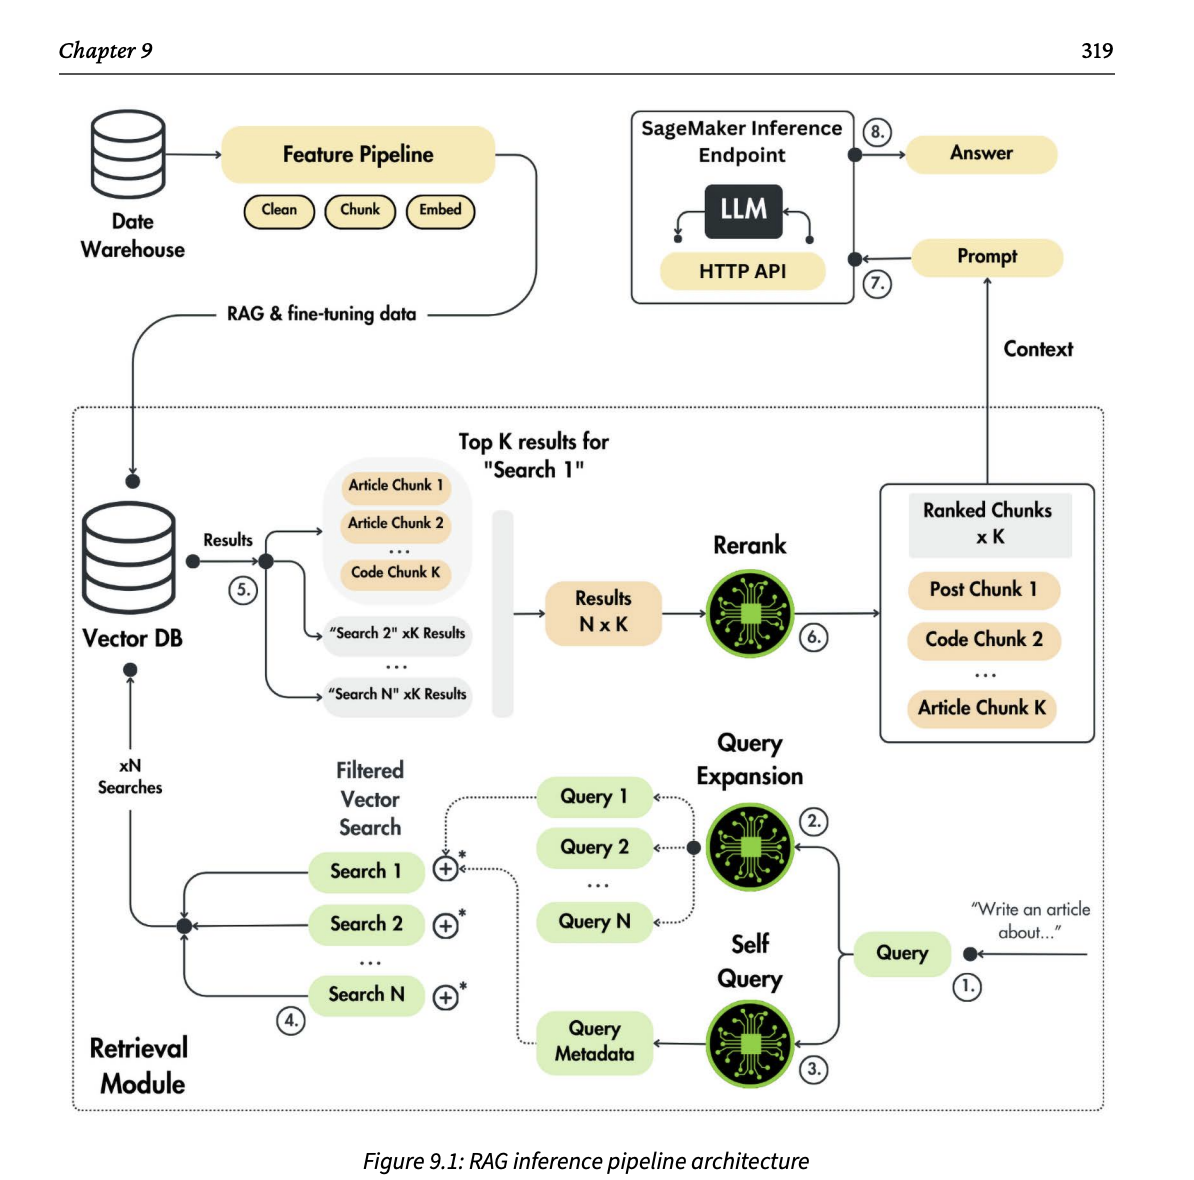
Query expansion & Self querying using a foundation model

1. Query expansion 

Query expansion will cover mutliple aspects of query in different ways, so that while during the query embedding search , we won't miss embedding which might not match based on our embeddings in vector database

2. Self querying.

To get the metadata 

Agent Guardrails:

Input Guardrails : use before_model_callback (Google ADK)
Output Guardrails: use after_model_callback (Google ADK)
Tool Guardrails: use before_tool_callback (google ADK)

Bedrock Guardrails:

Content filtering for prompts and responses
    Word filtering - can remove words in prompts and in responses as per our wish Eg: NSFW words
    Topic filtering - Same applies for controversial topics
    Profanities
    Personal Identifiable Information PII (masking)- phone number, SSN, address
    Contextual grounding check , it actually prevents haluucination by measuring the grounding percentage like how relevant is the response to the context it received

    These all can be incorporated into agents and Knowledge bases

    May also can configure the blocked message response


Bedrock Guardrails - Automated Reasoning checks

    Useful for enforcing complex policies 
    
    Bedrock Guardrails - Automated Reasoning checks
Useful for enforcing complex policies just like programmatic enforcement just like in CCA -F using claude sdk,